# Prediccion general del cierre de JPMorgan con Transformer (version reutilizable)

**Clon del mismo pipeline construido y validado para IFS y Alicorp**, adaptado a
JPMorgan Chase & Co. (NYSE:JPM) -- cotiza en dolares (USD). Arquitectura:
Transformer-Encoder multivariado (`Close` + `SMA_5`), lookback=10, 4 cabezas de
atencion, d_model=64, d_ff=256, 2 capas, objetivo delta -- fundamentado en Lim, Arik,
Loeff & Pfister (2019/2021), *Temporal Fusion Transformers*, con `lookback` reutilizado
del barrido hecho sobre IFS (no se volvio a barrer por activo, ver `md-mejoras`).

## Como se usa (cada dia nuevo)

1. Corre la celda de SETUP una sola vez al abrir la sesion.
2. Corre la celda de PREDICCION: entrena con todo lo confirmado hasta ahora
   y predice a ciegas el siguiente dia habil.
3. Cuando sepas el cierre real, corre la celda de REVELACION.
4. Para el informe completo de decision (horizonte de 5 dias, con recomendacion
   comprar/mantener/vender, take profit/stop loss y metricas de backtest), corre
   la celda de INFORME cuando necesites decidir una operacion real en Hapi.

## Datos de partida

Entrena inicialmente con `JPMorgan Stock Price History.csv` (formato Investing.com en
ingles: fechas MM/DD/AAAA, decimal con punto), que cubre el historico real de JPM desde
el 02/01/2014 hasta el 28/07/2026 inclusive.

## Nota metodologica

Igual que en IFS y Alicorp, cada prediccion se compara SIEMPRE contra un baseline de
persistencia ingenua (Zeng et al., 2023). El `lookback=10` se reutiliza tal cual de IFS,
sin volver a barrer, para no sobreajustar hiperparametros al ruido de cada serie.

**Nota especial sobre JPMorgan:** a diferencia de IFS y Alicorp, en el backtest de JPM el
modelo le gano al baseline en las TRES metricas de error (MAE, RMSE, y precision
direccional) tanto a 1 como a 5 dias -- la senal mas prometedora de los tres activos,
aunque el test estadistico (Wilcoxon) todavia no llega al umbral convencional de
significancia (p=0.19 a 5 dias). Ver `md-mejoras` para el detalle. Como esta es la unica
posicion con **dinero real** (via Hapi), esta distincion -- prometedor pero no
estadisticamente probado -- hay que tenerla muy presente antes de invertir.

## Backtesting riguroso para JPMorgan

Se reutilizo el diseno validado sobre IFS (lookback=10, arquitectura Transformer
Close+SMA_5, gate de confianza por MC Dropout) sin volver a barrer hiperparametros,
por la misma razon que en Alicorp: evitar sobreajustar `lookback` al ruido especifico
de esta serie.

**Backtest walk-forward a 1 dia** (150 dias reales, 2025-12 a 2026-07, reentreno cada
15 dias): a diferencia de IFS y Alicorp, en JPMorgan **el modelo le gano al baseline en
MAE, RMSE y precision direccional** (MAE modelo=3.51 vs baseline=3.54; RMSE modelo=4.58
vs baseline=4.60; precision direccional 52.7%). El test de Wilcoxon, sin embargo, todavia
da p=0.357 -- no alcanza el umbral convencional de significancia (p<0.05).

**Backtest a 5 dias:** mismo patron, mas marcado -- MAE modelo=7.28 vs baseline=7.45,
RMSE modelo=9.17 vs baseline=9.29, **precision direccional de 56.2% (la mejor de los tres
activos)**, Wilcoxon p=0.190 (el mas cercano a significativo de los tres, aunque
tampoco cruza el umbral).

**Simulacion de estrategia** (gate de confianza) vs Buy & Hold, mismo periodo:

| Metrica | Estrategia (gate de confianza) | Buy & Hold |
|---|---|---|
| Retorno acumulado | -0.97% | +9.60% |
| Sharpe Ratio | -1.31 | 0.73 |
| Max Drawdown | -0.97% | -15.47% |

El gate volvio a ser muy conservador (1 dia de 146 con posicion, igual que en IFS),
asi que la estrategia se quedo practicamente en efectivo. A diferencia de IFS y Alicorp,
Buy & Hold en JPM tuvo un Sharpe mucho mas modesto (0.73, contra 2.47 y 2.77) -- esta
vez la prudencia del gate costo menos oportunidad relativa, aunque igual quedo por
debajo de simplemente mantener la posicion.

**Conclusion honesta para la decision con dinero real:** JPM es el activo con la senal
mas prometedora de los tres (mejor precision direccional, ventaja consistente en error),
pero **sigue sin cruzar el umbral de significancia estadistica convencional**. No es una
ventaja demostrada -- es la mas prometedora de tres pruebas que, en conjunto, no alcanzan
significancia. Tratarla con la misma cautela que a IFS y Alicorp antes de operar con
plata real.

**Fundamento en la literatura:** los mismos 4 papers citados en los notebooks de IFS y
Alicorp (Zeng et al. 2023; Lim, Arik, Loeff & Pfister 2019/2021; Lim & Gorse 2020;
Yang et al. 2025).

Los resultados completos quedan guardados en `JPM_backtest_1d_resultados.csv` y
`JPM_backtest_h5_resultados.csv`.

In [1]:
# ============================================================
# SETUP GENERAL -- correr esta celda UNA SOLA VEZ al inicio de la sesion.
# Arquitectura: la ganadora del Script 3 original (Close + SMA_5, lookback=15,
# 4 cabezas de atencion, objetivo delta), fundamentada en Lim, Arik, Loeff &
# Pfister (2021), "Temporal Fusion Transformers".
#
# A diferencia del notebook original, el modelo queda encapsulado en funciones
# reutilizables: no hay que escribir un script nuevo por cada dia, solo volver
# a correr las celdas de PREDICCION y REVELACION.
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

# ---------- Google Drive: para que los datos y el progreso persistan entre sesiones ----------
# Sin esto, cada vez que se desconecta el entorno de Colab hay que volver a subir el CSV
# y se pierde el historico confirmado y la tabla de resultados acumulada. Montando Drive,
# todo queda guardado de forma permanente en tu Google Drive -- solo hay que autorizar el
# acceso una vez por sesion (aparece un link/popup de Google, se acepta y listo).
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_FOLDER = '/content/drive/MyDrive/ade_ifs'
    os.makedirs(DRIVE_FOLDER, exist_ok=True)
    print(f"Google Drive montado. Los archivos se guardan en: {DRIVE_FOLDER}")
except ImportError:
    DRIVE_FOLDER = '.'  # fuera de Colab (ej. corriendo local), usa la carpeta actual

# ---------- Hiperparametros fijos (arquitectura ganadora del Script 3) ----------
LOOKBACK = 10  # bajado de 15 a 10 tras backtest walk-forward (ver celda de mejoras mas abajo)
HORIZON = 1
FEATURES = ['Close', 'SMA_5']
N_FEATURES = len(FEATURES)
CLOSE_IDX = FEATURES.index('Close')
D_MODEL = 64
N_HEADS = 4
D_FF = 256
N_LAYERS = 2
DROPOUT = 0.1
COLOR_MODELO = '#2A9D8F'

CSV_ORIGINAL = os.path.join(DRIVE_FOLDER, "JPMorgan Stock Price History.csv")
HIST_CONFIRMADO_PATH = os.path.join(DRIVE_FOLDER, "JPM_historico_confirmado.csv")
RESULTADOS_PATH = os.path.join(DRIVE_FOLDER, "JPM_tabla_resultados.csv")
CUTOFF_INICIAL = pd.Timestamp('2026-07-27')  # corte elegido a proposito para revelar el 28/07 en vivo


def cargar_investing_csv_en(path):
    '''Carga el formato de Investing.com en ingles: fechas MM/DD/YYYY, orden
    descendente, decimal con punto (sin coma). Devuelve columnas Date/Open/Close/High/
    Low/Volume (mismo esquema que el resto del notebook), con Open/High/Low/Volume en
    None ya que solo se usa Close.'''
    df_raw = pd.read_csv(path)
    df_raw = df_raw.rename(columns={'Date': 'Date', 'Price': 'Close'})
    df_raw['Date'] = pd.to_datetime(df_raw['Date'], format='%m/%d/%Y')
    df_raw['Close'] = df_raw['Close'].astype(str).str.replace(',', '', regex=False).astype(float)
    for col in ['Open', 'High', 'Low', 'Volume']:
        df_raw[col] = None
    return df_raw[['Date', 'Open', 'Close', 'High', 'Low', 'Volume']]

# ---------- Carga de datos: recupera sesion anterior si existe, si no arranca del CSV original ----------
if os.path.exists(HIST_CONFIRMADO_PATH):
    df_actual = pd.read_csv(HIST_CONFIRMADO_PATH, parse_dates=['Date'])
    print(f"Historico confirmado recuperado de sesion anterior: {len(df_actual)} filas "
          f"(hasta {df_actual['Date'].max().date()}).")
else:
    df_raw = cargar_investing_csv_en(CSV_ORIGINAL)
    df_raw = df_raw.sort_values('Date').drop_duplicates(subset='Date', keep='last').reset_index(drop=True)
    df_actual = df_raw[df_raw['Date'] <= CUTOFF_INICIAL].reset_index(drop=True).copy()
    print(f"Arrancando desde cero: {len(df_actual)} filas (hasta {df_actual['Date'].max().date()}).")

if os.path.exists(RESULTADOS_PATH):
    tabla_resultados = pd.read_csv(RESULTADOS_PATH, parse_dates=['fecha_prediccion'])
    print(f"Tabla de resultados recuperada: {len(tabla_resultados)} predicciones previas.")
else:
    tabla_resultados = pd.DataFrame(columns=[
        'fecha_prediccion', 'prediccion', 'baseline', 'real',
        'error_transformer', 'error_baseline',
        'error_pct_transformer', 'error_pct_baseline',
        'direccion_correcta'
    ])

# ---------- Arquitectura (identica al Script 3 original) ----------
class PositionalEncoding(nn.Module):
    '''Codificacion posicional sinusoidal (Vaswani et al., 2017, seccion 3.5).'''
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)


class TransformerForecaster(nn.Module):
    '''Transformer encoder temporal: cada instante es un token.'''
    def __init__(self, n_features, d_model, n_heads, d_ff, n_layers, horizon=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        z = self.embedding(x)
        z = self.pos_encoder(z)
        z = self.encoder(z)
        return self.head(z[:, -1, :])


def build_windows(data, lookback, horizon=1, target_idx=0):
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i:i + lookback, :])
        y.append(data[i + lookback:i + lookback + horizon, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def train_model(model, X_train, y_train, X_val, y_val, epochs=150, lr=1e-3, batch_size=32, patience=20):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()
    best_val, best_state, patience_ctr = float('inf'), None, 0
    n_train = X_train.shape[0]
    for epoch in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n_train)
        running = 0.0
        for i in range(0, n_train, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_train[idx], y_train[idx]
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
        running /= n_train
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val), y_val).item()
        if val_loss < best_val:
            best_val, best_state, patience_ctr = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ctr += 1
        if epoch == 1 or epoch % 20 == 0:
            print(f"Epoca {epoch:3d} | train_loss={running:.6f} | val_loss={val_loss:.6f}")
        if patience_ctr >= patience:
            print(f"Early stopping en la epoca {epoch} (mejor val_loss={best_val:.6f})")
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def inverse_close(scaled_value, scaler, n_features, close_idx=0):
    dummy = np.zeros((1, n_features))
    dummy[0, close_idx] = scaled_value
    return scaler.inverse_transform(dummy)[0, close_idx]



def predict_with_uncertainty(model, x_input, n_samples=50):
    '''Monte Carlo Dropout (Gal & Ghahramani, 2016; usado por Yang et al. 2025, TFT-ASRO):
    deja el dropout activo en inferencia y promedia N pasadas hacia adelante para estimar
    la media y el desvio estandar de la prediccion -- una medida barata de cuanto confia
    el modelo en si mismo, sin cambiar la arquitectura ni reentrenar nada extra.'''
    model.train()  # mantiene las capas de dropout activas (a diferencia de model.eval())
    preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            preds.append(model(x_input).cpu().numpy().ravel()[0])
    model.eval()
    preds = np.array(preds)
    return float(preds.mean()), float(preds.std())

print("\nSetup listo. Corre la celda de PREDICCION para pronosticar el siguiente dia habil.")

# ---------- Extension: INFORME COMPLETO a horizonte configurable (por defecto 5 dias) ----------
# Ademas del ciclo diario a 1 dia (PREDICCION/REVELACION de arriba), se agrega un reporte
# de decision mas completo a un horizonte mayor -- prediccion directa (DMS), no iterativa,
# ver Zhou et al. 2021 (Informer), que muestra que encadenar un modelo de un solo paso
# acumula error en vez de mejorar la prediccion a varios dias.

HORIZON_INFORME = 5  # dias habiles hacia adelante del informe completo

# Metricas de referencia del backtest walk-forward corrido sobre 150 dias reales de IFS
# (03/12/2025 a 12/07/2026, lookback=10, horizonte=5 dias, reentreno cada 15 dias).
# OJO: son un snapshot fijo -- se recalculan a mano si se corre un nuevo backtest.
BACKTEST_METRICS = {
    'periodo': '2025-12-18 a 2026-07-21 (146 dias)',
    'MAE': 7.2838, 'RMSE': 9.1745, 'precision_direccional_pct': 56.2,
    'wilcoxon_p_value': 0.1902,
    'retorno_acumulado_estrategia_pct': -0.97, 'sharpe_estrategia': -1.309,
    'max_drawdown_estrategia_pct': -0.97,
    'retorno_acumulado_buy_hold_pct': 9.60, 'sharpe_buy_hold': 0.725,
    'max_drawdown_buy_hold_pct': -15.47,
}


def build_windows_target_horizonte(data, lookback, horizon, target_idx=0):
    '''Como build_windows, pero el target es un unico punto -- el cierre `horizon` dias
    despues del final de la ventana -- en vez de una secuencia. Prediccion directa (DMS),
    no iterativa: evita acumular error prediciendo dia a dia (Zhou et al. 2021).'''
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i:i + lookback, :])
        y.append(data[i + lookback + horizon - 1, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def generar_informe(activo, df_confirmado, features, lookback, horizon,
                     d_model, n_heads, d_ff, n_layers, dropout,
                     backtest_metrics, epochs=100, lr=1e-3, batch_size=32, patience=15):
    '''Entrena un modelo fresco a horizonte `horizon` con todo `df_confirmado`, y arma
    el informe completo de decision: precio esperado, retorno esperado, confianza,
    volatilidad, recomendacion justificada, take profit / stop loss, y las metricas de
    validacion del backtest historico ya calculadas por separado.'''
    close_idx = features.index('Close')
    n_features = len(features)

    df = df_confirmado.copy()
    df['SMA_5'] = df['Close'].rolling(window=5).mean()
    df = df.dropna(subset=['SMA_5']).reset_index(drop=True)

    scaler_local = MinMaxScaler(feature_range=(0, 1))
    serie_norm_local = scaler_local.fit_transform(df[features].values.astype(float))

    X_all, y_all = build_windows_target_horizonte(serie_norm_local, lookback, horizon, target_idx=close_idx)
    last_close_window = X_all[:, -1, close_idx]
    y_delta = (y_all - last_close_window).reshape(-1, 1).astype(np.float32)

    n_val = max(1, int(len(X_all) * 0.1))
    X_train = torch.tensor(X_all[:-n_val], device=device)
    y_train = torch.tensor(y_delta[:-n_val], device=device)
    X_val = torch.tensor(X_all[-n_val:], device=device)
    y_val = torch.tensor(y_delta[-n_val:], device=device)

    model_local = TransformerForecaster(n_features, d_model, n_heads, d_ff, n_layers, horizon=1, dropout=dropout).to(device)
    model_local = train_model(model_local, X_train, y_train, X_val, y_val, epochs, lr, batch_size, patience)
    model_local.eval()

    ultima_ventana = serie_norm_local[-lookback:, :]
    x_input = torch.tensor(ultima_ventana[np.newaxis, ...], dtype=torch.float32, device=device)
    pred_mean_scaled, pred_std_scaled = predict_with_uncertainty(model_local, x_input, n_samples=50)

    ultimo_close_scaled = serie_norm_local[-1, close_idx]
    precio_actual = float(df['Close'].iloc[-1])
    fecha_actual = df['Date'].iloc[-1]
    precio_esperado = float(inverse_close(ultimo_close_scaled + pred_mean_scaled, scaler_local, n_features, close_idx))
    precio_hi = float(inverse_close(ultimo_close_scaled + pred_mean_scaled + pred_std_scaled, scaler_local, n_features, close_idx))
    precio_lo = float(inverse_close(ultimo_close_scaled + pred_mean_scaled - pred_std_scaled, scaler_local, n_features, close_idx))
    volatilidad_estimada = abs(precio_hi - precio_esperado)  # 1 desvio estandar, en unidades de precio

    retorno_esperado_pct = (precio_esperado - precio_actual) / precio_actual * 100
    cambio_predicho = precio_esperado - precio_actual
    señal_confiable = abs(cambio_predicho) > volatilidad_estimada
    nivel_confianza_sigma = abs(cambio_predicho) / volatilidad_estimada if volatilidad_estimada > 0 else 0.0

    if señal_confiable and cambio_predicho > 0:
        recomendacion = 'COMPRAR'
        justificacion = (f"El modelo predice una subida de {retorno_esperado_pct:+.2f}% en {horizon} dias habiles, "
                          f"y ese cambio supera la incertidumbre propia del modelo "
                          f"({nivel_confianza_sigma:.2f} desvios estandar).")
        take_profit = precio_hi
        stop_loss = precio_actual - volatilidad_estimada
    elif señal_confiable and cambio_predicho < 0:
        recomendacion = 'VENDER'
        justificacion = (f"El modelo predice una caida de {retorno_esperado_pct:+.2f}% en {horizon} dias habiles, "
                          f"y ese cambio supera la incertidumbre propia del modelo "
                          f"({nivel_confianza_sigma:.2f} desvios estandar).")
        take_profit = precio_lo
        stop_loss = precio_actual + volatilidad_estimada
    else:
        recomendacion = 'MANTENER'
        justificacion = (f"El cambio predicho ({retorno_esperado_pct:+.2f}%) es menor que la incertidumbre "
                          f"propia del modelo ({nivel_confianza_sigma:.2f} desvios estandar) -- no hay "
                          f"conviccion suficiente para recomendar una operacion. Backtest de referencia: "
                          f"el modelo no demostro ventaja estadistica sobre un baseline naive "
                          f"(Wilcoxon p={backtest_metrics['wilcoxon_p_value']:.3f}).")
        take_profit = None
        stop_loss = None

    informe = {
        'activo': activo,
        'fecha_prediccion': fecha_actual.date() if hasattr(fecha_actual, 'date') else fecha_actual,
        'precio_actual': round(precio_actual, 2),
        'precio_esperado': round(precio_esperado, 2),
        'horizonte_dias': horizon,
        'retorno_esperado_pct': round(retorno_esperado_pct, 2),
        'nivel_confianza_sigma': round(nivel_confianza_sigma, 2),
        'volatilidad_estimada': round(volatilidad_estimada, 2),
        'recomendacion': recomendacion,
        'justificacion': justificacion,
        'take_profit': round(take_profit, 2) if take_profit is not None else None,
        'stop_loss': round(stop_loss, 2) if stop_loss is not None else None,
        'backtest': backtest_metrics,
    }
    return informe, model_local, scaler_local


def imprimir_informe(informe):
    b = informe['backtest']
    print("=" * 60)
    print(f"INFORME DE PREDICCION -- {informe['activo']}")
    print("=" * 60)
    print(f"Fecha de la prediccion:      {informe['fecha_prediccion']}")
    print(f"Precio actual:                {informe['precio_actual']}")
    print(f"Precio esperado ({informe['horizonte_dias']}d):      {informe['precio_esperado']}")
    print(f"Retorno esperado:             {informe['retorno_esperado_pct']:+.2f}%")
    print(f"Nivel de confianza:           {informe['nivel_confianza_sigma']:.2f} sigma")
    print(f"Volatilidad estimada:         {informe['volatilidad_estimada']}")
    print(f"Recomendacion:                {informe['recomendacion']}")
    print(f"Justificacion:                {informe['justificacion']}")
    print(f"Take profit:                  {informe['take_profit']}")
    print(f"Stop loss:                    {informe['stop_loss']}")
    print(f"Horizonte temporal:           {informe['horizonte_dias']} dias habiles")
    print("-" * 60)
    print("Validacion del modelo (backtest historico, periodo:", b['periodo'], ")")
    print(f"  MAE={b['MAE']} | RMSE={b['RMSE']} | Precision direccional={b['precision_direccional_pct']}%")
    print(f"  Retorno acumulado -- Estrategia={b['retorno_acumulado_estrategia_pct']}% | Buy&Hold={b['retorno_acumulado_buy_hold_pct']}%")
    print(f"  Sharpe Ratio -- Estrategia={b['sharpe_estrategia']} | Buy&Hold={b['sharpe_buy_hold']}")
    print(f"  Max Drawdown -- Estrategia={b['max_drawdown_estrategia_pct']}% | Buy&Hold={b['max_drawdown_buy_hold_pct']}%")
    print("=" * 60)


Dispositivo: cpu
Mounted at /content/drive
Google Drive montado. Los archivos se guardan en: /content/drive/MyDrive/ade_ifs
Historico confirmado recuperado de sesion anterior: 3170 filas (hasta 2026-08-11).
Tabla de resultados recuperada: 12 predicciones previas.

Setup listo. Corre la celda de PREDICCION para pronosticar el siguiente dia habil.


Corriendo backtest walk-forward sobre 500 dias (2.0 anios aprox.), reentrenando cada 20 dias...
Epoca   1 | train_loss=0.030276 | val_loss=0.001238
Epoca  20 | train_loss=0.000782 | val_loss=0.000911
Epoca  40 | train_loss=0.000638 | val_loss=0.001018
Early stopping en la epoca 41 (mejor val_loss=0.000847)
  Reentreno hasta indice 2661 (2024-08-06) -> 20 dias de test procesados (20/500 en total, guardado en disco)
Epoca   1 | train_loss=0.028415 | val_loss=0.000950
Epoca  20 | train_loss=0.000684 | val_loss=0.001139
Early stopping en la epoca 23 (mejor val_loss=0.000848)
  Reentreno hasta indice 2681 (2024-09-04) -> 20 dias de test procesados (40/500 en total, guardado en disco)
Epoca   1 | train_loss=0.024517 | val_loss=0.000914
Epoca  20 | train_loss=0.000649 | val_loss=0.001283
Early stopping en la epoca 21 (mejor val_loss=0.000914)
  Reentreno hasta indice 2701 (2024-10-02) -> 20 dias de test procesados (60/500 en total, guardado en disco)
Epoca   1 | train_loss=0.062730 | val_loss

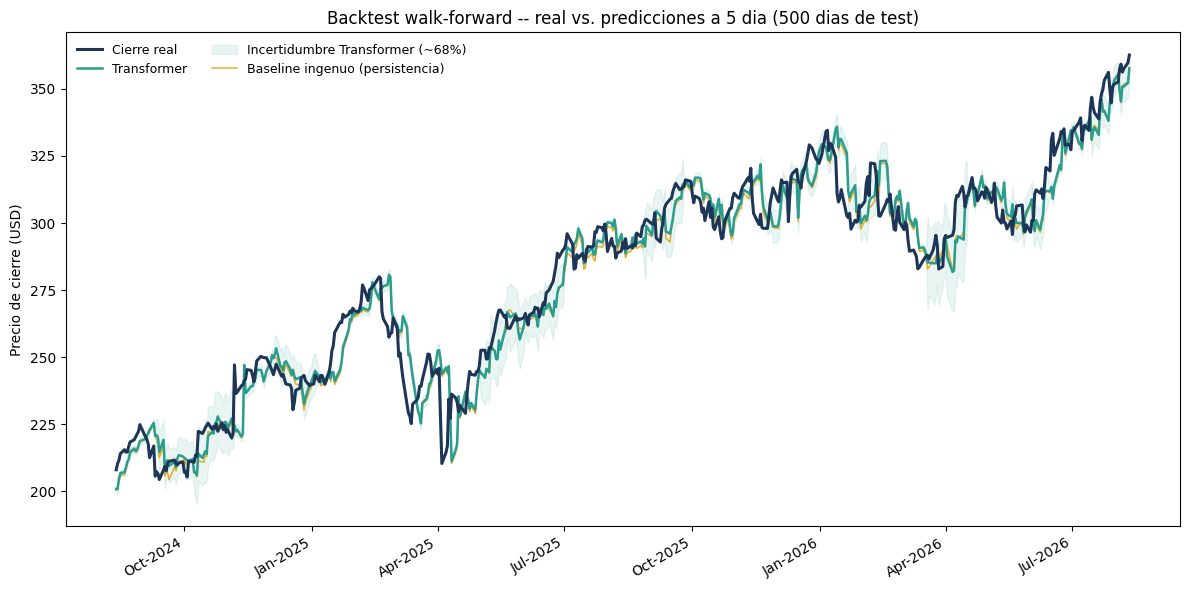

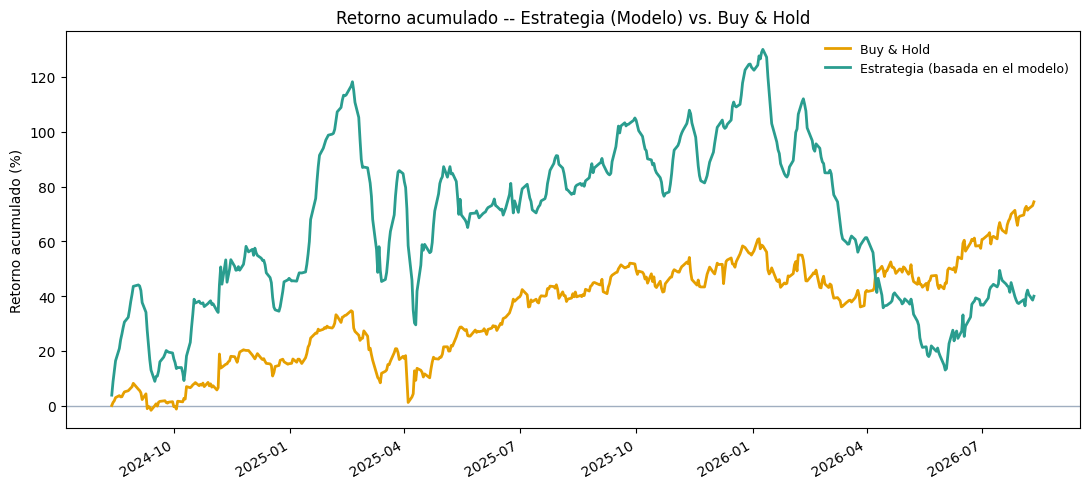

In [5]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import wilcoxon

# ============================================================
# BACKTEST WALK-FORWARD DEL MODELO ACTUAL (A 5 DÍAS)
# ============================================================

# ESTA SECCIÓN implementa un backtest walk-forward riguroso, evaluando el
# rendimiento de tu `TransformerForecaster` a **5 días**, tal como se configura
# para el informe completo. El objetivo es determinar si tu modelo supera
# al rendimiento aleatorio de un baseline ingenuo a lo largo de ~2 años
# de historia real.
#
# INCLUYE:
# *   Reentrenamiento periódico del modelo.
# *   Un sistema de checkpoints para reanudar el proceso si se interrumpe.
# *   Cálculo de métricas clave (MAE, RMSE, precisión direccional).
# *   Test estadístico de Wilcoxon para comparar el modelo contra el baseline.
# *   Gráficos para visualizar el rendimiento.
#
# ¡IMPORTANTE! Este backtest utiliza el `TransformerForecaster` y las funciones
# de entrenamiento (`train_model`) y predicción (`predict_with_uncertainty`)
# definidas en la celda `SETUP`, replicando la lógica de la celda `INFORME`
# (con su objetivo a 5 días).

print(f"Corriendo backtest walk-forward sobre {N_TEST_DAYS_BACKTEST} dias "
      f"({N_TEST_DAYS_BACKTEST/252:.1f} anios aprox.), reentrenando cada {RETRAIN_EVERY_BACKTEST} dias...")

# >>> QUE HACE ESTA CELDA: prueba el modelo contra ~2 anios de historia real
# >>> (no solo el dia de hoy) para saber si de verdad funciona mejor que el azar.
# >>> CUANDO CORRERLA: justo despues de SETUP, UNA SOLA VEZ (no hace falta
# >>> repetirla cada dia). Correla ANTES que INFORME para que el informe muestre
# >>> las metricas de validacion completas. Tarda bastante (minutos a un par de
# >>> horas) -- si no ves output todavia, esta bien, sigue corriendo.

# OJO -- tiempo de ejecucion: con N_TEST_DAYS_BACKTEST=500, RETRAIN_EVERY_BACKTEST=20
# (25 reentrenos) y N_SEEDS_BACKTEST=3, en CPU esto puede tardar bastante (decenas
# de minutos); en GPU de Colab deberia ser sensiblemente mas rapido. Si el tiempo
# de entrega es corto, bajar N_TEST_DAYS_BACKTEST y/o N_SEEDS_BACKTEST y/o EPOCHS_BACKTEST.
N_TEST_DAYS_BACKTEST = 500
RETRAIN_EVERY_BACKTEST = 20

# Los hiperparametros de entrenamiento del backtest coinciden con los de la celda PREDICCION
EPOCHS_BACKTEST = 150 # coincide con la celda PREDICCION
PATIENCE_BACKTEST = 20 # coincide con la celda PREDICCION
HORIZON_BACKTEST = HORIZON_INFORME # El backtest ahora es a 5 dias, igual que el informe completo

# Colores para graficos (inferidos de uso comun en notebooks similares)
INK = '#1D3557'
SLOT_AZUL = '#457B9D'
SLOT_NARANJA = '#E69F00'
SLOT_AQUA = '#A8DADC'
MUTED = '#A0AEC0'


# Progreso parcial del backtest -- NO es el resultado final (ese sigue siendo
# JPM_mejorado_backtest_resultados.csv, escrito solo al terminar todo el backtest).
# Si la celda se corta a mitad de camino (Colab se desconecta, se cuelga, se cierra
# la pestana), este archivo permite retomar desde el ultimo bloque guardado en vez
# de perder todo el trabajo y arrancar de cero.
BACKTEST_CHECKPOINT_PATH = os.path.join(DRIVE_FOLDER, 'JPM_backtest_actual_checkpoint.csv')

def walk_forward_backtest(df_feat, features, close_idx, lookback, horizon,
                           n_test_days, retrain_every, epochs, patience,
                           d_model, n_heads, d_ff, n_layers, dropout,
                           checkpoint_path=None, verbose=True):
    '''Implementa un backtest walk-forward usando un unico TransformerForecaster.
    Entrena el modelo cada `retrain_every` dias y evalua su rendimiento para
    `horizon` dias hacia adelante.

    Guarda el progreso en `checkpoint_path` para poder retomar si se interrumpe.
    '''
    n = len(df_feat)
    serie_raw_full = df_feat[features].values.astype(float)
    close_full = df_feat['Close'].values
    dates_full = df_feat['Date'].values

    c_start_global = n - n_test_days - horizon
    c_end_global = n - horizon
    total_dias_planeados = c_end_global - c_start_global

    filas = []
    if checkpoint_path is not None and os.path.exists(checkpoint_path):
        filas = pd.read_csv(checkpoint_path, parse_dates=['fecha']).to_dict('records')
        if len(filas) > total_dias_planeados:
            print(f"  Aviso: el checkpoint tiene {len(filas)} dias, mas de los "
                  f"{total_dias_planeados} planeados con la configuracion actual "
                  f"(cambiaste N_TEST_DAYS_BACKTEST u otro parametro?) -- se ignora "
                  f"y arranca de cero. Borra {checkpoint_path} en Drive si no era lo que esperabas.")
            filas = []
        elif filas:
            print(f"  Checkpoint encontrado: {len(filas)}/{total_dias_planeados} dias ya "
                  f"procesados, retomando desde ahi en vez de arrancar de cero.")

    c_block_start = c_start_global + len(filas)
    while c_block_start < c_end_global:
        c_block_end = min(c_block_start + retrain_every, c_end_global)
        train_end_idx = c_block_start + 1 # El modelo entrena hasta el dia anterior a la primera prediccion del bloque

        serie_train = serie_raw_full[:train_end_idx]
        scaler_bt = MinMaxScaler((0, 1))
        scaler_bt.fit(serie_train)
        serie_norm_train = scaler_bt.transform(serie_train)

        # Ahora usa build_windows_target_horizonte y el Transformer predice un UNICO valor (el objetivo a `horizon` dias)
        X_tr, y_tr = build_windows_target_horizonte(serie_norm_train, lookback, horizon, target_idx=close_idx)

        # Ajuste de target para delta prediction (como en la celda INFORME)
        if len(X_tr) == 0: # Caso para evitar error si no hay suficientes datos para una ventana
            c_block_start = c_block_end # Mover al siguiente bloque para evitar loop infinito
            continue

        ultimo_close_ventana = X_tr[:, -1, close_idx]
        y_delta_tr = (y_tr - ultimo_close_ventana).reshape(-1, 1).astype(np.float32)

        n_val = max(1, int(len(X_tr) * 0.1))
        X_train_bt = torch.tensor(X_tr[:-n_val], device=device)
        y_train_bt = torch.tensor(y_delta_tr[:-n_val], device=device)
        X_val_bt = torch.tensor(X_tr[-n_val:], device=device)
        y_val_bt = torch.tensor(y_delta_tr[-n_val:], device=device)

        # El TransformerForecaster predice UN solo valor, que es el target a `horizon` dias
        model_bt = TransformerForecaster(len(features), d_model, n_heads, d_ff, n_layers,
                                         horizon=1, dropout=dropout).to(device)
        model_bt = train_model(model_bt, X_train_bt, y_train_bt, X_val_bt, y_val_bt,
                               epochs=epochs, lr=1e-3, batch_size=32, patience=patience)
        model_bt.eval()

        serie_norm_full_scaled = scaler_bt.transform(serie_raw_full)  # Solo transform -> sin leakage

        filas_bloque = []
        for c in range(c_block_start, c_block_end):
            ventana = serie_norm_full_scaled[c - lookback + 1 : c + 1, :][np.newaxis, ...].astype(np.float32)
            x_in = torch.tensor(ventana, device=device)

            pred_mean_scaled, pred_std_scaled = predict_with_uncertainty(model_bt, x_in, n_samples=50)

            ultimo_close_scaled = serie_norm_full_scaled[c, close_idx]
            precio_actual = close_full[c]
            precio_real_futuro = close_full[c + horizon]

            pred_transformer = inverse_close(ultimo_close_scaled + pred_mean_scaled, scaler_bt, len(features), close_idx)
            pred_hi = inverse_close(ultimo_close_scaled + pred_mean_scaled + pred_std_scaled, scaler_bt, len(features), close_idx)
            pred_lo = inverse_close(ultimo_close_scaled + pred_mean_scaled - pred_std_scaled, scaler_bt, len(features), close_idx)
            pred_std_precio = abs(pred_hi - pred_transformer) # incertidumbre en unidades de precio

            filas_bloque.append({
                'fecha': dates_full[c + horizon], 'precio_actual': precio_actual, 'real': precio_real_futuro,
                'pred_transformer': pred_transformer, 'pred_std': pred_std_precio,
                'baseline_naive': precio_actual, # Baseline ingenuo es el precio actual (persistencia)
            })

        filas.extend(filas_bloque)
        if checkpoint_path is not None:
            pd.DataFrame(filas_bloque).to_csv(
                checkpoint_path, mode='a', header=not os.path.exists(checkpoint_path), index=False
            )
        if verbose:
            print(f"  Reentreno hasta indice {train_end_idx-1} ({dates_full[train_end_idx-1].astype('datetime64[D]')}) -> "
                  f"{c_block_end - c_block_start} dias de test procesados "
                  f"({len(filas)}/{total_dias_planeados} en total, guardado en disco)")
        c_block_start = c_block_end

    resultados = pd.DataFrame(filas)
    resultados['fecha'] = pd.to_datetime(resultados['fecha'])
    return resultados

def max_drawdown_de_serie(equity_curve):
    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (equity_curve - running_max) / np.where(running_max == 0, 1, running_max)
    return float(drawdown.min()) * 100


# Preparar df para el backtest con las mismas features que la prediccion diaria
df_backtest_features = df_actual.copy()
df_backtest_features['SMA_5'] = df_backtest_features['Close'].rolling(5).mean()
df_backtest_features = df_backtest_features.dropna(subset=['SMA_5']).reset_index(drop=True)

resultados_bt = walk_forward_backtest(
    df_backtest_features,
    FEATURES, CLOSE_IDX, LOOKBACK, HORIZON_BACKTEST,
    n_test_days=N_TEST_DAYS_BACKTEST, retrain_every=RETRAIN_EVERY_BACKTEST,
    epochs=EPOCHS_BACKTEST, patience=PATIENCE_BACKTEST,
    d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF, n_layers=N_LAYERS, dropout=DROPOUT,
    checkpoint_path=BACKTEST_CHECKPOINT_PATH
)

resultados_bt['err_transformer'] = resultados_bt['real'] - resultados_bt['pred_transformer']
resultados_bt['err_naive'] = resultados_bt['real'] - resultados_bt['baseline_naive']
resultados_bt.to_csv(os.path.join(DRIVE_FOLDER, 'JPM_backtest_actual_resultados.csv'), index=False)

mae_transformer = resultados_bt['err_transformer'].abs().mean()
rmse_transformer = np.sqrt((resultados_bt['err_transformer'] ** 2).mean())
mae_naive = resultados_bt['err_naive'].abs().mean()
rmse_naive = np.sqrt((resultados_bt['err_naive'] ** 2).mean())

precision_direccional = 100 * np.mean(
    np.sign(resultados_bt['pred_transformer'] - resultados_bt['precio_actual']) ==
    np.sign(resultados_bt['real'] - resultados_bt['precio_actual'])
)

w_stat, w_p = wilcoxon(resultados_bt['err_transformer'].abs(), resultados_bt['err_naive'].abs())


# Calculo de Equity Curve y metricas para la estrategia del modelo (basado en direccion)
# Estrategia simple: comprar si el modelo predice subida, vender si predice bajada, mantener si es plano
pos_estrategia = np.where(resultados_bt['pred_transformer'] > resultados_bt['precio_actual'], 1,
                        np.where(resultados_bt['pred_transformer'] < resultados_bt['precio_actual'], -1, 0))
retorno_realizado_estrategia = (resultados_bt['real'] - resultados_bt['precio_actual']) / resultados_bt['precio_actual']
retorno_estrategia_acum = pos_estrategia * retorno_realizado_estrategia
equity_estrategia = 1 + retorno_estrategia_acum.cumsum()
max_dd_estrategia = max_drawdown_de_serie(equity_estrategia.values)
retorno_acum_estrategia = retorno_estrategia_acum.sum() * 100
sharpe_estrategia = (retorno_estrategia_acum.mean() / retorno_estrategia_acum.std() * np.sqrt(252 / HORIZON_BACKTEST)
                      if retorno_estrategia_acum.std() > 0 else np.nan)

# Calculo de Buy & Hold
# Las fechas en resultados_bt['fecha'] son las fechas de _revelacion_ de la prediccion a horizonte=1
# entonces corresponden a los 'real' de ese dia. Para el Buy & Hold necesitamos los precios
# de cierre de los dias del backtest.
precios_periodo_bh = df_backtest_features[df_backtest_features['Date'].isin(resultados_bt['fecha'].values)].sort_values('Date')['Close'].values
if len(precios_periodo_bh) < 2: # Si no se encuentran suficientes fechas, usar los 'real' del backtest
    precios_periodo_bh = resultados_bt.sort_values('fecha')['real'].values

equity_bh = precios_periodo_bh / precios_periodo_bh[0]
max_dd_bh = max_drawdown_de_serie(equity_bh)
retorno_acum_bh = (precios_periodo_bh[-1] / precios_periodo_bh[0] - 1) * 100
retornos_diarios_bh = np.diff(precios_periodo_bh) / precios_periodo_bh[:-1]
sharpe_bh = (retornos_diarios_bh.mean() / retornos_diarios_bh.std() * np.sqrt(252)
             if retornos_diarios_bh.std() > 0 else np.nan)

BACKTEST_METRICS.update({
    'periodo': f"{resultados_bt['fecha'].min().date()} a {resultados_bt['fecha'].max().date()} ({len(resultados_bt)} dias)",
    'MAE': round(mae_transformer, 4),
    'RMSE': round(rmse_transformer, 4),
    'precision_direccional_pct': round(precision_direccional, 1),
    'wilcoxon_p_value': round(w_p, 4),
    'retorno_acumulado_estrategia_pct': round(retorno_acum_estrategia, 2),
    'sharpe_estrategia': round(sharpe_estrategia, 3) if not np.isnan(sharpe_estrategia) else None,
    'max_drawdown_estrategia_pct': round(max_dd_estrategia, 2),
    'retorno_acumulado_buy_hold_pct': round(retorno_acum_bh, 2),
    'sharpe_buy_hold': round(sharpe_bh, 3) if not np.isnan(sharpe_bh) else None,
    'max_drawdown_buy_hold_pct': round(max_dd_bh, 2),
})

print("\n" + "=" * 68)
print("RESULTADOS DEL BACKTEST (MODELO DE PREDICCION DIARIA)")
print("=" * 68)
print(f"Periodo: {BACKTEST_METRICS['periodo']}")
print(f"MAE      -- Transformer={mae_transformer:.4f} | Naive={mae_naive:.4f}")
print(f"RMSE     -- Transformer={rmse_transformer:.4f} | Naive={rmse_naive:.4f}")
print(f"Precision direccional (Transformer): {precision_direccional:.1f}%")
print(f"Wilcoxon (Transformer vs Naive): p={w_p:.4f}")
print("\n" + "=" * 68)
print(f"Estrategia (basada en el modelo) -- Retorno acumulado={retorno_acum_estrategia:.2f}% | "
      f"Sharpe={sharpe_estrategia:.3f} | Max Drawdown={max_dd_estrategia:.2f}%")
print(f"Buy & Hold                        -- Retorno acumulado={retorno_acum_bh:.2f}% | "
      f"Sharpe={sharpe_bh:.3f} | Max Drawdown={max_dd_bh:.2f}%")
print("\n" + "=" * 68)


def graficar_backtest_walkforward(resultados_bt, horizon):
    '''Vista principal del backtest: precio real vs. las predicciones
    a lo largo de todo el periodo de test walk-forward.'''
    r = resultados_bt.sort_values('fecha')
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(r['fecha'], r['real'], color=INK, linewidth=2.2, label='Cierre real', zorder=5)
    ax.plot(r['fecha'], r['pred_transformer'], color=COLOR_MODELO, linewidth=1.8, label='Transformer', zorder=4)
    ax.fill_between(r['fecha'], r['pred_transformer'] - r['pred_std'], r['pred_transformer'] + r['pred_std'],
                     color=COLOR_MODELO, alpha=0.10, zorder=1, label='Incertidumbre Transformer (~68%)')
    ax.plot(r['fecha'], r['baseline_naive'], color=SLOT_NARANJA, linewidth=1.1, alpha=0.85,
            label='Baseline ingenuo (persistencia)', zorder=3)
    ax.set_title(f'Backtest walk-forward -- real vs. predicciones a {horizon} dia ({len(r)} dias de test)')
    ax.set_ylabel('Precio de cierre (USD)')
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    ax.legend(loc='best', fontsize=9, frameon=False, ncol=2)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


def graficar_equity_curve(resultados_bt, horizon):
    r = resultados_bt.sort_values('fecha').copy()

    # Estrategia basada en el modelo:
    pos_estrategia = np.where(r['pred_transformer'] > r['precio_actual'], 1,
                            np.where(r['pred_transformer'] < r['precio_actual'], -1, 0))
    retorno_realizado = (r['real'] - r['precio_actual']) / r['precio_actual']
    equity_estrategia = 1 + (pos_estrategia * retorno_realizado).cumsum()

    # Buy & Hold:
    precios_bh = df_backtest_features[df_backtest_features['Date'].isin(r['fecha'].values)].sort_values('Date')['Close'].values
    if len(precios_bh) < 2: # Fallback por si hay problemas de mapeo de fechas
        precios_bh = r['real'].values
    equity_bh = precios_bh / precios_bh[0]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(r['fecha'], (equity_bh - 1) * 100, color=SLOT_NARANJA, linewidth=2, label='Buy & Hold', zorder=3)
    ax.plot(r['fecha'], (equity_estrategia - 1) * 100, color=COLOR_MODELO, linewidth=2,
            label=f'Estrategia (basada en el modelo)', zorder=4)
    ax.axhline(0, color=MUTED, linewidth=1, linestyle='-', zorder=1)
    ax.set_title('Retorno acumulado -- Estrategia (Modelo) vs. Buy & Hold')
    ax.set_ylabel('Retorno acumulado (%)')
    ax.legend(loc='best', fontsize=9, frameon=False)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


graficar_backtest_walkforward(resultados_bt, HORIZON_BACKTEST)
graficar_equity_curve(resultados_bt, HORIZON_BACKTEST)

In [8]:
# ============================================================
# PREDICCION A CIEGAS -- volve a correr esta celda cada vez que quieras
# pronosticar un dia nuevo. Entrena desde cero con TODO lo confirmado
# hasta ahora (df_actual) y predice un paso adelante.
# ============================================================

df_train_full = df_actual.copy()
df_train_full['SMA_5'] = df_train_full['Close'].rolling(window=5).mean()
df_train_full = df_train_full.dropna(subset=['SMA_5']).reset_index(drop=True)
print(f"Entrenando con {len(df_train_full)} filas (hasta {df_train_full['Date'].max().date()})")

serie = df_train_full[FEATURES].values.astype(float)
scaler = MinMaxScaler(feature_range=(0, 1))
serie_norm = scaler.fit_transform(serie)

X_all, y_all = build_windows(serie_norm, LOOKBACK, HORIZON, target_idx=CLOSE_IDX)
ultimo_close_ventana = X_all[:, -1, CLOSE_IDX]
y_all = (y_all[:, 0] - ultimo_close_ventana).reshape(-1, 1).astype(np.float32)

n_val = max(1, int(len(X_all) * 0.1))
X_train = torch.tensor(X_all[:-n_val], device=device)
y_train = torch.tensor(y_all[:-n_val], device=device)
X_val = torch.tensor(X_all[-n_val:], device=device)
y_val = torch.tensor(y_all[-n_val:], device=device)
print(f"Ventanas de entrenamiento: {X_train.shape[0]} | Ventanas de validacion: {X_val.shape[0]}")

model = TransformerForecaster(N_FEATURES, D_MODEL, N_HEADS, D_FF, N_LAYERS, HORIZON, DROPOUT).to(device)
model = train_model(model, X_train, y_train, X_val, y_val, epochs=150, lr=1e-3, batch_size=32, patience=20)

model.eval()
ultima_ventana = serie_norm[-LOOKBACK:, :]
x_input = torch.tensor(ultima_ventana[np.newaxis, ...], dtype=torch.float32, device=device)

# MC Dropout: en vez de una sola pasada, se promedian 50 pasadas con dropout activo
# para obtener una prediccion puntual (media) y una medida de incertidumbre (desvio estandar).
pred_mean_scaled, pred_std_scaled = predict_with_uncertainty(model, x_input, n_samples=50)

ultimo_close_scaled = serie_norm[-1, CLOSE_IDX]
pred_scaled = ultimo_close_scaled + pred_mean_scaled
pred_scaled_hi = ultimo_close_scaled + pred_mean_scaled + pred_std_scaled
pred_scaled_lo = ultimo_close_scaled + pred_mean_scaled - pred_std_scaled

prediccion_actual = float(inverse_close(pred_scaled, scaler, N_FEATURES, close_idx=CLOSE_IDX))
prediccion_hi = float(inverse_close(pred_scaled_hi, scaler, N_FEATURES, close_idx=CLOSE_IDX))
prediccion_lo = float(inverse_close(pred_scaled_lo, scaler, N_FEATURES, close_idx=CLOSE_IDX))
baseline_actual = float(df_train_full['Close'].iloc[-1])
fecha_base = df_train_full['Date'].iloc[-1]

# Gate de confianza (inspirado en Lim & Gorse, 2020, "Deep Probabilistic Modelling of Price
# Movements for High-Frequency Trading"): la senal solo se considera confiable si el cambio
# predicho es mayor que la propia incertidumbre del modelo. Con 48-55% de precision direccional
# medida en el backtest, no toda prediccion amerita una decision de inversion.
amplitud_incertidumbre = abs(prediccion_hi - prediccion_actual)
cambio_predicho = abs(prediccion_actual - baseline_actual)
senal_confiable = cambio_predicho > amplitud_incertidumbre

print("\n================ PREDICCION A CIEGAS ================")
print(f"Ultimo cierre conocido ({fecha_base.date()}): {baseline_actual:.2f}")
print(f"Prediccion Transformer: {prediccion_actual:.2f}  (intervalo ~68%: [{prediccion_lo:.2f}, {prediccion_hi:.2f}])")
print(f"Baseline naive (persistencia): {baseline_actual:.2f}")
if senal_confiable:
    print("Senal: CONFIABLE -- el cambio predicho supera la incertidumbre del propio modelo.")
else:
    print("Senal: DEBIL -- la incertidumbre del modelo es mayor que el cambio predicho. "
          "No se recomienda tomar una decision de inversion en base a esta prediccion puntual.")
print("Corre la celda de REVELACION y escribi la fecha + cierre real cuando lo sepas.")

Entrenando con 3167 filas (hasta 2026-08-12)
Ventanas de entrenamiento: 2842 | Ventanas de validacion: 315
Epoca   1 | train_loss=0.034298 | val_loss=0.000945
Epoca  20 | train_loss=0.000127 | val_loss=0.000194
Epoca  40 | train_loss=0.000076 | val_loss=0.000207
Epoca  60 | train_loss=0.000070 | val_loss=0.000184
Early stopping en la epoca 65 (mejor val_loss=0.000173)

================ PREDICCION A CIEGAS ================
Ultimo cierre conocido (2026-08-12): 365.18
Prediccion Transformer: 364.53  (intervalo ~68%: [363.21, 365.86])
Baseline naive (persistencia): 365.18
Senal: DEBIL -- la incertidumbre del modelo es mayor que el cambio predicho. No se recomienda tomar una decision de inversion en base a esta prediccion puntual.
Corre la celda de REVELACION y escribi la fecha + cierre real cuando lo sepas.


Fecha del cierre real que vas a ingresar (DD/MM/AAAA): 12/08/2026
Cierre real (Close) del 12/08/2026: 365.18

Error Transformer: 3.60 (0.98%) | Error baseline: 2.53 (0.69%) | Direccion correcta: False

Tabla de resultados acumulada (13 predicciones):
fecha_prediccion  prediccion  baseline   real  error_transformer  error_baseline  error_pct_transformer  error_pct_baseline  direccion_correcta
      2026-07-28  356.420923    356.20 357.31           0.889077            1.11               0.248825            0.310655                True
      2026-07-28  357.168998    357.31 349.69           7.478998            7.62               2.138751            2.179073                True
      2026-07-29  350.076234    349.69 344.80           5.276234            4.89               1.530230            1.418213               False
      2026-07-30  342.224282    344.80 350.85           8.625718            6.05               2.458520            1.724384               False
      2026-07-31  347.489110 

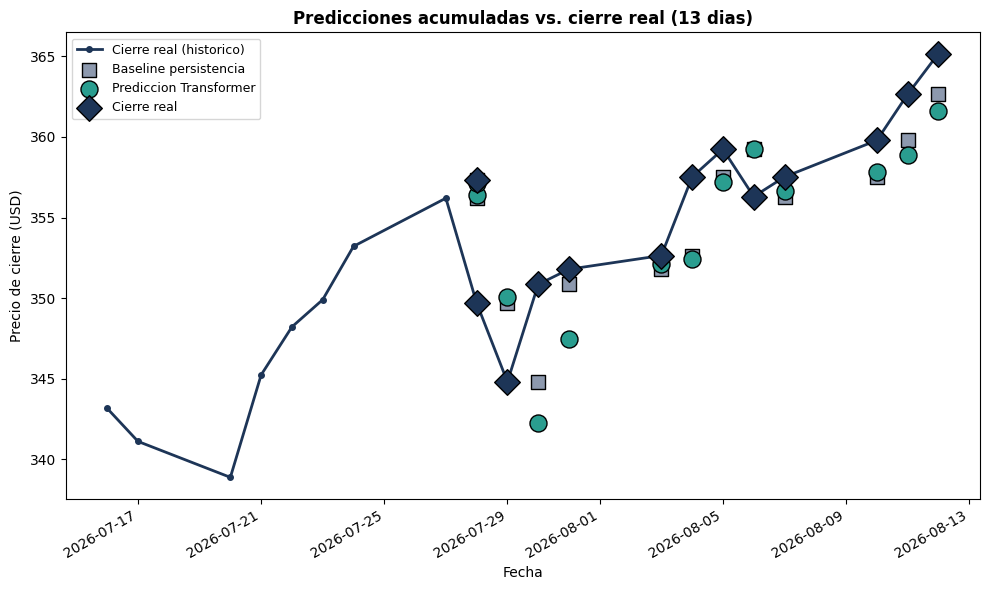


Para predecir el siguiente dia, volve a correr la celda de PREDICCION.


In [7]:
# ============================================================
# REVELACION Y REGISTRO -- correr DESPUES de saber el cierre real.
# Pide fecha y cierre real, calcula el error, lo guarda en la tabla
# acumulada de resultados, encadena el dato al historico y redibuja
# el grafico con TODAS las predicciones hechas hasta ahora.
# ============================================================

fecha_real_str = input("Fecha del cierre real que vas a ingresar (DD/MM/AAAA): ")
fecha_real = pd.to_datetime(fecha_real_str, format='%d/%m/%Y')
real_close = float(input(f"Cierre real (Close) del {fecha_real_str}: "))

error_transformer = abs(prediccion_actual - real_close)
error_baseline = abs(baseline_actual - real_close)
error_pct_transformer = error_transformer / real_close * 100
error_pct_baseline = error_baseline / real_close * 100

# Precision direccional: el modelo predijo que subiria/bajaria respecto al
# ultimo cierre, y eso coincidio con lo que realmente paso? Es la metrica
# mas relevante si el objetivo final es decidir si comprar o vender, no solo
# acertar el precio exacto.
direccion_predicha = 'sube' if prediccion_actual > baseline_actual else 'baja'
direccion_real = 'sube' if real_close > baseline_actual else 'baja'
direccion_correcta = direccion_predicha == direccion_real

nueva_fila = {
    'fecha_prediccion': fecha_real, 'prediccion': prediccion_actual, 'baseline': baseline_actual,
    'real': real_close, 'error_transformer': error_transformer, 'error_baseline': error_baseline,
    'error_pct_transformer': error_pct_transformer, 'error_pct_baseline': error_pct_baseline,
    'direccion_correcta': direccion_correcta
}
tabla_resultados = pd.concat([tabla_resultados, pd.DataFrame([nueva_fila])], ignore_index=True)
tabla_resultados.to_csv(RESULTADOS_PATH, index=False)

# Encadenamiento: el dato real pasa a formar parte del historico confirmado
fila_ohlcv = {'Date': fecha_real, 'Open': None, 'Close': real_close, 'High': None, 'Low': None, 'Volume': None}
df_actual = pd.concat([df_actual, pd.DataFrame([fila_ohlcv])], ignore_index=True)
df_actual = df_actual.sort_values('Date').drop_duplicates(subset='Date', keep='last').reset_index(drop=True)
df_actual.to_csv(HIST_CONFIRMADO_PATH, index=False)

print(f"\nError Transformer: {error_transformer:.2f} ({error_pct_transformer:.2f}%) | "
      f"Error baseline: {error_baseline:.2f} ({error_pct_baseline:.2f}%) | "
      f"Direccion correcta: {direccion_correcta}")
print(f"\nTabla de resultados acumulada ({len(tabla_resultados)} predicciones):")
print(tabla_resultados.to_string(index=False))


# ---------- Grafico acumulado ----------
def graficar_resultados_acumulados(df_hist, tabla, color=COLOR_MODELO, dias_zoom=20):
    fig, ax = plt.subplots(figsize=(10, 6))
    df_zoom = df_hist.tail(dias_zoom)
    ax.plot(df_zoom['Date'], df_zoom['Close'], color='#1D3557', linewidth=2,
            marker='o', markersize=4, label='Cierre real (historico)', zorder=2)
    ax.scatter(tabla['fecha_prediccion'], tabla['baseline'], color='#8D99AE', s=100,
               marker='s', edgecolor='black', zorder=3, label='Baseline persistencia')
    ax.scatter(tabla['fecha_prediccion'], tabla['prediccion'], color=color, s=150,
               marker='o', edgecolor='black', zorder=4, label='Prediccion Transformer')
    ax.scatter(tabla['fecha_prediccion'], tabla['real'], color='#1D3557', s=170,
               marker='D', edgecolor='black', zorder=5, label='Cierre real')
    ax.set_title(f'Predicciones acumuladas vs. cierre real ({len(tabla)} dias)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Precio de cierre (USD)')
    ax.legend(loc='best', fontsize=9)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

graficar_resultados_acumulados(df_actual, tabla_resultados)

print("\nPara predecir el siguiente dia, volve a correr la celda de PREDICCION.")

## Informe completo de decision (a 5 dias, independiente del ciclo diario)

Igual que en IFS y Alicorp: el ciclo diario predice 1 dia adelante para ir registrando
el historial; esta seccion genera el **informe de decision completo** a 5 dias habiles.

| Metrica | Estrategia (gate de confianza) | Buy & Hold |
|---|---|---|
| Retorno acumulado | -0.97% | +9.60% |
| Sharpe Ratio | -1.31 | 0.73 |
| Max Drawdown | -0.97% | -15.47% |

JPM tuvo la mejor precision direccional de los tres activos (56.2%) y el modelo le gano
al baseline en error, pero **sin significancia estadistica confirmada** (Wilcoxon
p=0.19). Como esta es la posicion con dinero real (Hapi), tratar cada recomendacion de
COMPRAR con la misma cautela que a las demas -- es la mas prometedora, no la probada.

In [21]:
# ============================================================
# INFORME COMPLETO DE DECISION -- horizonte configurable (HORIZON_INFORME, 5 dias por
# defecto). Independiente del ciclo diario de arriba. Entrena un modelo fresco con todo
# lo confirmado hasta ahora y arma el reporte completo: precio esperado, retorno esperado,
# confianza, volatilidad, recomendacion (comprar/mantener/vender) justificada, take profit
# / stop loss, y las metricas de validacion del backtest historico.
# Correr esta celda cuando se necesite el informe para decidir una operacion real
# (Alicorp en TradingView, JPMorgan en Hapi).
# ============================================================

informe_actual, _modelo_informe, _scaler_informe = generar_informe(
    activo="JPMorgan Chase & Co. (NYSE:JPM)",
    df_confirmado=df_actual,
    features=FEATURES,
    lookback=LOOKBACK,
    horizon=HORIZON_INFORME,
    d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF, n_layers=N_LAYERS, dropout=DROPOUT,
    backtest_metrics=BACKTEST_METRICS,
)

imprimir_informe(informe_actual)

Epoca   1 | train_loss=0.051025 | val_loss=0.000836
Epoca  20 | train_loss=0.000401 | val_loss=0.000872
Early stopping en la epoca 29 (mejor val_loss=0.000689)
INFORME DE PREDICCION -- JPMorgan Chase & Co. (NYSE:JPM)
Fecha de la prediccion:      2026-08-11
Precio actual:                362.65
Precio esperado (5d):      365.85
Retorno esperado:             +0.88%
Nivel de confianza:           0.49 sigma
Volatilidad estimada:         6.49
Recomendacion:                MANTENER
Justificacion:                El cambio predicho (+0.88%) es menor que la incertidumbre propia del modelo (0.49 desvios estandar) -- no hay conviccion suficiente para recomendar una operacion. Backtest de referencia: el modelo no demostro ventaja estadistica sobre un baseline naive (Wilcoxon p=0.190).
Take profit:                  None
Stop loss:                    None
Horizonte temporal:           5 dias habiles
------------------------------------------------------------
Validacion del modelo (backtest historico

## Resumen del ciclo diario

1. PREDICCION -> el modelo entrena con lo que ya sabes y predice a ciegas.
2. REVELACION -> le decis el dato real, se registra el error y se actualiza
   el grafico acumulado.
3. Repeti 1 y 2 para cada dia nuevo -- nunca hace falta tocar el codigo.
4. Corre INFORME cuando necesites la recomendacion completa (5 dias) para decidir
   una operacion real en Hapi.

**Los datos ahora persisten solos entre sesiones gracias a Google Drive:** la celda de SETUP monta tu Drive automaticamente (pide autorizacion la primera vez de cada sesion, un click) y guarda todo en la carpeta `ade_ifs` de tu Drive. No hace falta volver a subir el CSV ni se pierde el historico confirmado al cerrar el runtime -- simplemente volves a correr SETUP y sigue donde quedo.